# 01 — Exploration des données Olist
**Objectif** : Comprendre la structure de chaque fichier CSV avant tout nettoyage.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


print('Librairies chargees avec succes.')

Librairies chargees avec succes.


## 1. Chargement des fichiers CSV

In [2]:
from pathlib import Path

DATA_PATH = Path('C:/Users/cymad/olist_ecommerce_analysis/data/raw')
orders       = pd.read_csv(DATA_PATH / 'olist_orders_dataset.csv')
items        = pd.read_csv(DATA_PATH / 'olist_order_items_dataset.csv')
customers    = pd.read_csv(DATA_PATH / 'olist_customers_dataset.csv')
reviews      = pd.read_csv(DATA_PATH / 'olist_order_reviews_dataset.csv')
payments     = pd.read_csv(DATA_PATH / 'olist_order_payments_dataset.csv')
products     = pd.read_csv(DATA_PATH / 'olist_products_dataset.csv')
sellers      = pd.read_csv(DATA_PATH / 'olist_sellers_dataset.csv')
translations = pd.read_csv(DATA_PATH / 'product_category_name_translation.csv')

datasets = {
    'orders': orders,
    'items': items,
    'customers': customers,
    'reviews': reviews,
    'payments': payments,
    'products': products,
    'sellers': sellers,
    'translations': translations
}

print('Datasets charges avec succes.')



Datasets charges avec succes.


## 2. Aperçu rapide de chaque table

In [4]:
for name, df in datasets.items():
    print('=' * 55)
    print(f'TABLE : {name.upper()}')
    print('=' * 55)
    print(f'lignes : {df.shape[0]}, colonnes : {df.shape[1]}')
    display(df.head())
    
    

TABLE : ORDERS
lignes : 99441, colonnes : 8


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


TABLE : ITEMS
lignes : 112650, colonnes : 7


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


TABLE : CUSTOMERS
lignes : 99441, colonnes : 5


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


TABLE : SELLERS
lignes : 3095, colonnes : 4


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


TABLE : TRANSLATIONS
lignes : 71, colonnes : 2


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## 3. Types de données et valeurs manquantes

In [7]:
for name, df in datasets.items():
    missing = df.isnull().sum()
    info = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.notnull().sum(),
        'missing': missing
    })
    print('=' * 55)
    print(f'TABLE : {name.upper()}')
    print('=' * 55)
    display(info)
   

TABLE : ORDERS


,dtype,non_null,missing
order_id,object,99441,0
customer_id,object,99441,0
order_status,object,99441,0
order_purchase_timestamp,object,99441,0
order_approved_at,object,99281,160
order_delivered_carrier_date,object,97658,1783
order_delivered_customer_date,object,96476,2965
order_estimated_delivery_date,object,99441,0


TABLE : ITEMS


,dtype,non_null,missing
order_id,object,112650,0
order_item_id,int64,112650,0
product_id,object,112650,0
seller_id,object,112650,0
shipping_limit_date,object,112650,0
price,float64,112650,0
freight_value,float64,112650,0


TABLE : CUSTOMERS


...

,dtype,non_null,missing
product_id,object,32951,0
product_category_name,object,32341,610
product_name_lenght,float64,32341,610
product_description_lenght,float64,32341,610
product_photos_qty,float64,32341,610
product_weight_g,float64,32949,2
product_length_cm,float64,32949,2
product_height_cm,float64,32949,2
product_width_cm,float64,32949,2


TABLE : SELLERS


,dtype,non_null,missing
seller_id,object,3095,0
seller_zip_code_prefix,int64,3095,0
seller_city,object,3095,0
seller_state,object,3095,0


TABLE : TRANSLATIONS


,dtype,non_null,missing
product_category_name,object,71,0
product_category_name_english,object,71,0


## 4. Statistiques descriptives

In [13]:
# Colonnes dates connues par table
date_cols_map = {
    'orders':   ['order_purchase_timestamp', 'order_approved_at',
                 'order_delivered_carrier_date', 'order_delivered_customer_date',
                 'order_estimated_delivery_date'],
    'items':    ['shipping_limit_date'],
    'reviews':  ['review_creation_date', 'review_answer_timestamp'],
}

# Conversion en datetime dans chaque dataset
for table_name, cols in date_cols_map.items():
    for col in cols:
        datasets[table_name][col] = pd.to_datetime(datasets[table_name][col])

print('Conversions datetime effectuées.')

Conversions datetime effectuées.


In [ ]:
for name, df in datasets.items():
    print('=' * 55)
    print(f'STATS DESCRIPTIVES — {name.upper()}')
    print('=' * 55)

    # Colonnes numériques
    num_cols = df.select_dtypes(include='number').columns.tolist()
    # Colonnes texte
    obj_cols = df.select_dtypes(include='object').columns.tolist()
    # Colonnes dates
    date_cols = df.select_dtypes(include='datetime').columns.tolist()

    if num_cols:
        print(f'\n  Colonnes numériques ({len(num_cols)}) :')
        display(df[num_cols].describe().round(2))

    if obj_cols:
        print(f'\n  Colonnes texte ({len(obj_cols)}) :')
        display(df[obj_cols].describe())

    if date_cols:
        print(f'\n  Colonnes dates ({len(date_cols)}) :')
        date_stats = pd.DataFrame({
           'min':   [df[col].min() for col in date_cols],
           'max':   [df[col].max() for col in date_cols],
           'plage (jours)': [(df[col].max() - df[col].min()).days for col in date_cols],
           'nulls': [df[col].isnull().sum() for col in date_cols],
        }, index=date_cols)
        display(date_stats)
    

## 5. Analyse des statuts de commandes

Distribution des statuts de commandes :
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


FileNotFoundError: [Errno 2] No such file or directory: '../docs/01_statuts_commandes.png'

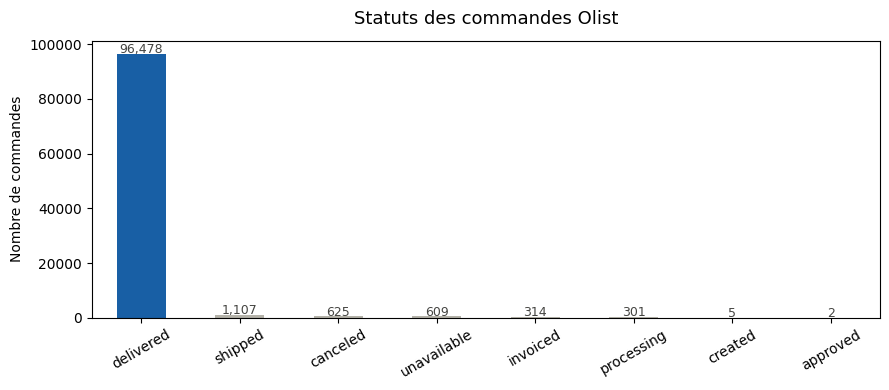

In [17]:
status_counts = orders['order_status'].value_counts()
print('Distribution des statuts de commandes :')
print(status_counts)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#185FA5' if s == 'delivered' else '#B4B2A9' for s in status_counts.index]
status_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='none')
ax.set_title('Statuts des commandes Olist', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Nombre de commandes')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(status_counts):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9, color='#444441')
plt.tight_layout()
plt.savefig('../docs/01_statuts_commandes.png', dpi=150)
plt.show()

## 6. Distribution des notes clients

In [ ]:
score_counts = reviews['review_score'].value_counts().sort_index()
print('Distribution des notes :')
print(score_counts)
print(f'\nNote moyenne : {reviews["review_score"].mean():.2f} / 5')

fig, ax = plt.subplots(figsize=(7, 4))
palette = ['#A32D2D', '#D85A30', '#888780', '#639922', '#3B6D11']
bars = ax.bar(score_counts.index, score_counts.values, color=palette, edgecolor='none', width=0.6)
ax.set_title('Distribution des avis clients', fontsize=13, pad=12)
ax.set_xlabel('Note (1 à 5 étoiles)')
ax.set_ylabel('Nombre d\'avis')
for bar, val in zip(bars, score_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', fontsize=9, color='#444441')
plt.tight_layout()
plt.savefig('../docs/01_distribution_notes.png', dpi=150)
plt.show()

## 7. Volume de commandes par mois

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly = orders.groupby('month').size()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind='bar', ax=ax, color='#185FA5', edgecolor='none')
ax.set_title('Volume de commandes par mois', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Nombre de commandes')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../docs/01_commandes_par_mois.png', dpi=150)
plt.show()

## 8. Distribution des prix et frais de port

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

items['price'].clip(upper=500).hist(bins=50, ax=axes[0], color='#185FA5', edgecolor='none')
axes[0].set_title('Distribution des prix (≤ 500 R$)', fontsize=12)
axes[0].set_xlabel('Prix (R$)')
axes[0].set_ylabel('Fréquence')

items['freight_value'].clip(upper=100).hist(bins=50, ax=axes[1], color='#3B6D11', edgecolor='none')
axes[1].set_title('Distribution des frais de port (≤ 100 R$)', fontsize=12)
axes[1].set_xlabel('Frais de port (R$)')
axes[1].set_ylabel('Fréquence')

plt.suptitle('Prix et frais de port', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../docs/01_prix_frais_port.png', dpi=150)
plt.show()

print(f'Prix moyen      : {items["price"].mean():.2f} R$')
print(f'Prix médian     : {items["price"].median():.2f} R$')
print(f'Frais de port moyen : {items["freight_value"].mean():.2f} R$')

## 9. Top 10 catégories de produits

In [ ]:
items_cat = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_cat = items_cat.merge(translations, on='product_category_name', how='left')

top_cat = items_cat.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_cat.sort_values().plot(kind='barh', ax=ax, color='#185FA5', edgecolor='none')
ax.set_title('Top 10 catégories par chiffre d\'affaires', fontsize=13, pad=12)
ax.set_xlabel('Chiffre d\'affaires (R$)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../docs/01_top_categories.png', dpi=150)
plt.show()

## 10. Répartition géographique des clients

In [ ]:
state_counts = customers['customer_state'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
state_counts.sort_values().plot(kind='barh', ax=ax, color='#1D9E75', edgecolor='none')
ax.set_title('Top 15 états par nombre de clients', fontsize=13, pad=12)
ax.set_xlabel('Nombre de clients')
ax.set_ylabel('État')
plt.tight_layout()
plt.savefig('../docs/01_clients_par_etat.png', dpi=150)
plt.show()

print('\nTop 5 états :')
print(state_counts.head())

## 11. Résumé des observations

| Observation | Détail |
|---|---|
| Colonnes dates | Toutes en `object` → à convertir en `datetime` |
| Valeurs manquantes | `review_comment_title`, `review_comment_message`, `product_category_name` |
| Doublons | À vérifier sur `order_id` dans reviews |
| Outliers prix | Quelques produits > 5 000 R$ |
| Variable cible | `delivery_delay_days` à créer |

→ Ces points seront traités dans **02_cleaning.ipynb**